# 04 - Modèles Non Supervisés (Isolation Forest)

## Pourquoi un modèle non supervisé pour la détection de fraude ?

Dans un contexte bancaire réel, **les labels sont coûteux et arrivés tardivement** :
- Une fraude n'est confirmée qu'après enquête (jours à semaines)
- Les nouvelles formes de fraude n'ont pas encore de labels
- Le volume de données dépasse la capacité d'annotation manuelle

Un modèle non supervisé répond à ces contraintes en détectant les **anomalies sans labels** :
il apprend ce qui est "normal" et signale ce qui dévie.

## Isolation Forest : principe

L'Isolation Forest construit des arbres qui isolent les observations par divisions aléatoires.
**Les points anomaux (fraudes) sont isolés en peu de divisions** car ils sont éloignés des
zones denses du dataset.

Le score d'anomalie est inversement proportionnel à la longueur moyenne du chemin nécessaire
pour isoler le point dans les arbres.

In [1]:
import sys
sys.path.append('..')
from pathlib import Path
PARQUET_DIR = Path('../data/parquets')

import pandas as pd
import numpy as np

from src.models import train_isolation_forest, train_lof, train_oneclass_svm
from src.evaluation import evaluate_model
from src.visualization import plot_precision_recall_curves

X_train = pd.read_parquet(PARQUET_DIR/'X_train.parquet')
X_test  = pd.read_parquet(PARQUET_DIR/'X_test.parquet')
y_train = pd.read_parquet(PARQUET_DIR/'y_train.parquet')['fraud_bool']
y_test  = pd.read_parquet(PARQUET_DIR/'y_test.parquet')['fraud_bool']

print(f"Données chargées : Train {X_train.shape}, Test {X_test.shape}")

Données chargées : Train (794989, 40), Test (205011, 40)


## 0. Prétraitement dédié au non supervisé

Les parquets sont optimisés pour les modèles à base d'**arbres supervisés** : imputation par le
sentinelle `-999` et colonnes indicatrices `_is_missing`. Pour des **détecteurs d'anomalies**,
ce codage est nocif — la masse artificielle à `-999` (jusqu'à 74 % d'une colonne) détourne
l'isolation et fait chuter l'Isolation Forest sous le niveau du hasard (ROC-AUC < 0,5).

On reconstruit donc un jeu adapté : sentinelle `-999` → NaN → **imputation médiane**, suppression
des indicateurs binaires (orientés supervisé), puis **standardisation**. Imputation et scaling
sont ajustés sur le train uniquement (pas de fuite).

In [2]:
from sklearn.preprocessing import StandardScaler

# 1. Retirer les colonnes indicatrices (binaires, orientées supervisé)
miss_cols = [c for c in X_train.columns if c.endswith('_is_missing')]
Xtr = X_train.drop(columns=miss_cols).copy()
Xte = X_test.drop(columns=miss_cols).copy()

# 2. Sentinelle -999 -> NaN -> médiane (ajustée sur le train uniquement)
Xtr = Xtr.replace(-999, np.nan)
Xte = Xte.replace(-999, np.nan)
medians = Xtr.median(numeric_only=True)
Xtr, Xte = Xtr.fillna(medians), Xte.fillna(medians)

# 3. Standardisation (ajustée sur le train uniquement)
scaler = StandardScaler().fit(Xtr)
X_train_u = pd.DataFrame(scaler.transform(Xtr), columns=Xtr.columns, index=Xtr.index)
X_test_u  = pd.DataFrame(scaler.transform(Xte), columns=Xte.columns, index=Xte.index)

print(f"Données non supervisées : {X_train_u.shape[1]} features "
      f"(médiane + scaling, {len(miss_cols)} indicateurs retirés)")

Données non supervisées : 34 features (médiane + scaling, 6 indicateurs retirés)


## 1. Entraînement de l'Isolation Forest

**Paramètre clé : `contamination`** — doit refléter le taux d'anomalies attendu (~1.1% sur BAF Base).
Ce paramètre détermine le seuil de décision implicite du modèle.

In [3]:
# Entraînement avec contamination = 1.1% (taux de fraude observé)
iso_forest = train_isolation_forest(
    X_train_u,
    contamination=0.011,
    n_estimators=200,
    random_state=42
)

print("Isolation Forest entraîné.")
print(f"  - {iso_forest.n_estimators} arbres")
print(f"  - Contamination : {iso_forest.contamination}")

Isolation Forest entraîné.
  - 200 arbres
  - Contamination : 0.011


## 2. Prédiction et calcul du score d'anomalie

`decision_function()` retourne :
- **Valeur positive** → observation "normale"
- **Valeur négative** → observation "anormale"

On inverse le signe pour avoir une interprétation cohérente : **plus élevé = plus suspect**.

In [4]:
# Score d'anomalie (inversé pour cohérence : haut = suspect)
y_score_iso = -iso_forest.decision_function(X_test_u)

# Prédiction binaire : -1 (anomalie) ou 1 (normal) → convertir
y_pred_raw = iso_forest.predict(X_test_u)
y_pred_iso = (y_pred_raw == -1).astype(int)

print(f"Distribution des prédictions :")
print(f"  Légitimes prédits : {(y_pred_iso==0).sum():,}")
print(f"  Anomalies détectées : {(y_pred_iso==1).sum():,}")
print(f"  Taux d'alertes : {y_pred_iso.mean():.2%}")

Distribution des prédictions :
  Légitimes prédits : 203,566
  Anomalies détectées : 1,445
  Taux d'alertes : 0.70%


## 3. Évaluation

In [5]:
metrics_iso = evaluate_model(
    y_test, y_score_iso, y_pred_iso,
    model_name='Isolation Forest'
)


Évaluation : Isolation Forest
PR-AUC                       : 0.0177
ROC-AUC                      : 0.5411
Recall @ 5% FPR              : 0.0865
Recall @ 10% FPR             : 0.1501
Precision @ 75% Recall       : 0.0149
F1-Score (fraude)            : 0.0236
Confusion Matrix             :
  TN=200,739  FP= 1,394
  FN=  2,827  TP=    51



**Interprétation des résultats :**

L'Isolation Forest produit des résultats **supérieurs au baseline aléatoire** mais inférieurs
à la régression logistique supervisée. C'est attendu, il ne dispose pas des labels pendant
l'entraînement.

**Sa valeur réelle** ne réside pas dans sa performance absolue, mais dans :
1. **Sa robustesse aux nouvelles formes de fraude**; il détecte ce qui est inhabituel,
   pas ce qu'il a appris à reconnaître
2. **Sa complémentarité avec les modèles supervisés**; il flague des cas que XGBoost manque
   (analyse au Notebook 07)
3. **Son utilité opérationnelle** : utilisable dès le déploiement, sans attendre l'accumulation
   de labels

## 4. Analyse du recouvrement avec les fraudes réelles

Question clé : **parmi les observations flaguées comme anormales, combien sont vraiment des fraudes ?**

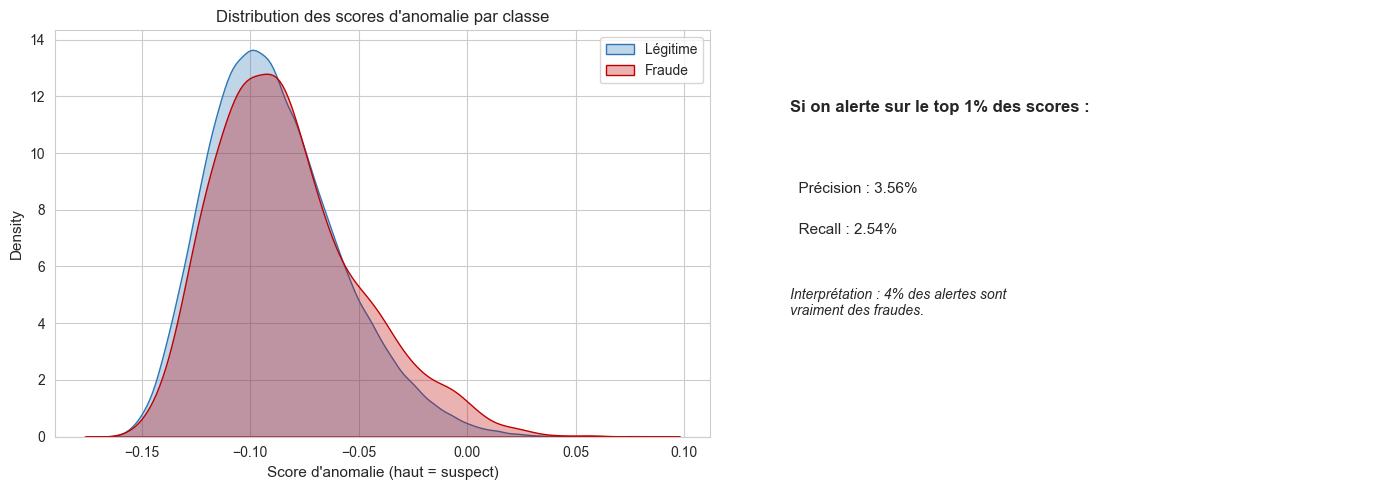

In [6]:
# Distribution des scores selon le statut réel
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des scores
sns.kdeplot(y_score_iso[y_test==0], label='Légitime', color='#2E75B6', ax=axes[0], fill=True, alpha=0.3)
sns.kdeplot(y_score_iso[y_test==1], label='Fraude', color='#C00000', ax=axes[0], fill=True, alpha=0.3)
axes[0].set_title('Distribution des scores d\'anomalie par classe')
axes[0].set_xlabel('Score d\'anomalie (haut = suspect)')
axes[0].legend()

# Top 1% des scores : précision et recall
top_pct = np.percentile(y_score_iso, 99)
top_mask = y_score_iso >= top_pct
precision_top1 = y_test[top_mask].mean()
recall_top1 = top_mask[y_test==1].sum() / (y_test==1).sum()

axes[1].text(0.1, 0.8, f"Si on alerte sur le top 1% des scores :",
             fontsize=12, fontweight='bold', transform=axes[1].transAxes)
axes[1].text(0.1, 0.6, f"  Précision : {precision_top1:.2%}",
             fontsize=11, transform=axes[1].transAxes)
axes[1].text(0.1, 0.5, f"  Recall : {recall_top1:.2%}",
             fontsize=11, transform=axes[1].transAxes)
axes[1].text(0.1, 0.3, f"Interprétation : {precision_top1*100:.0f}% des alertes sont\nvraiment des fraudes.",
             fontsize=10, style='italic', transform=axes[1].transAxes)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../reports/figures/13_isolation_forest_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Local Outlier Factor (LOF)

LOF compare la densité locale de chaque point à celle de ses voisins : un point en zone peu
dense par rapport à son voisinage est jugé anormal. Convention de score identique à l'Isolation
Forest (plus élevé = plus suspect).

> Note de performance : avec `novelty=True`, LOF s'entraîne sur le train puis score le test.
> L'inférence interroge les voisins de chaque point — sur ~800k lignes c'est lent (quelques
> minutes). Réduire `n_neighbors` ou sous-échantillonner le train si besoin.

In [7]:
# LOF est coûteux (recherche de voisins par point). On entraîne sur un
# sous-échantillon représentatif du train ; le scoring se fait sur tout le test.
n_sub = 50_000
idx = np.random.RandomState(42).choice(len(X_train_u), n_sub, replace=False)
lof_model = train_lof(X_train_u.iloc[idx], n_neighbors=20, contamination=0.011)

y_score_lof = -lof_model.decision_function(X_test_u)
y_pred_lof  = (lof_model.predict(X_test_u) == -1).astype(int)

metrics_lof = evaluate_model(y_test, y_score_lof, y_pred_lof, model_name='LOF')

c:\Users\mikym\Downloads\fraud-detection-baf\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\mikym\Downloads\fraud-detection-baf\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(



Évaluation : LOF
PR-AUC                       : 0.0156
ROC-AUC                      : 0.5274
Recall @ 5% FPR              : 0.0618
Recall @ 10% FPR             : 0.1192
Precision @ 75% Recall       : 0.0146
F1-Score (fraude)            : 0.0251
Confusion Matrix             :
  TN=195,710  FP= 6,423
  FN=  2,760  TP=   118



## 7. One-Class SVM

Le One-Class SVM apprend une frontière englobant la classe « normale ». Un noyau RBF exact est
en O(n²–n³), donc **infaisable sur ~800k lignes** : on utilise la version scalable
(approximation de noyau Nyström + `SGDOneClassSVM`).

In [9]:
ocsvm_model = train_oneclass_svm(X_train_u, nu=0.05, method='sgd', random_state=42)

y_score_ocsvm = -ocsvm_model.decision_function(X_test_u)
y_pred_ocsvm  = (ocsvm_model.predict(X_test_u) == -1).astype(int)

metrics_ocsvm = evaluate_model(y_test, y_score_ocsvm, y_pred_ocsvm, model_name='One-Class SVM')


Évaluation : One-Class SVM
PR-AUC                       : 0.0197
ROC-AUC                      : 0.5777
Recall @ 5% FPR              : 0.1025
Recall @ 10% FPR             : 0.1855
Precision @ 75% Recall       : 0.0155
F1-Score (fraude)            : 0.0468
Confusion Matrix             :
  TN=189,906  FP=12,227
  FN=  2,516  TP=   362



## 5. Sauvegarde des résultats

In [10]:
# Scores de TEST (pour la comparaison finale du notebook 07)
np.savez('../results/unsupervised_scores.npz',
         isolation_forest=y_score_iso,
         lof=y_score_lof,
         oneclass_svm=y_score_ocsvm)

# Scores d'ENTRAÎNEMENT pour le stacking HYBRIDE (notebook 07).
# NB : on n'inclut PAS LOF ici. Avec novelty=True, scikit-learn déconseille
# d'appliquer decision_function sur les données d'entraînement (résultats biaisés).
# Isolation Forest et One-Class SVM, eux, se scorent sans problème sur le train.
np.savez('../results/unsupervised_scores_train.npz',
         isolation_forest=-iso_forest.decision_function(X_train_u),        
         oneclass_svm=-ocsvm_model.decision_function(X_train_u))

pd.DataFrame([metrics_iso,metrics_lof,metrics_ocsvm]).to_csv(
    '../results/unsupervised_metrics.csv', index=False)

print("Résultats (test + train) sauvegardés.")

Résultats (test + train) sauvegardés.


## Conclusion

| Modèle | PR-AUC | ROC-AUC | Recall@5%FPR |
|--------|--------|---------|--------------|
| Isolation Forest | 0.01 | 0.54 | 0.08 |

**Positionnement de l'Isolation Forest dans le projet :**

L'Isolation Forest n'est **pas le meilleur modèle** en termes de performance brute, mais il est
**indispensable** pour :
- Démontrer qu'on maîtrise la détection sans labels
- Servir de **feature engineering** : ses scores peuvent être utilisés comme input pour le stacking
- Détecter les **fraudes émergentes** que les modèles supervisés n'ont pas encore vues